In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,0,1,0,44
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,10.0,South-East,Relatively New,1741.0,1550.0,1350.0,0,0,0,0,1,1,49
2,house,independent,48,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,1.0,NaN,Relatively New,NaN,33.0,NaN,0,0,0,0,0,1,0
3,flat,brisk lumbini terrace homes,109,1.50,6616.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,4.0,North,New Property,NaN,NaN,2267.0,0,1,0,0,0,1,37
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,20.0,East,Moderately Old,2727.0,NaN,NaN,0,1,0,0,1,1,49


In [5]:
df.shape

(3822, 23)

In [6]:
df.columns

Index(['property_type', 'society', 'sector', 'price_in_crore',
       'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom',
       'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area',
       'built_up_area', 'carpet_area', 'study room', 'servant room',
       'store room', 'pooja ghar', 'others', 'furnishing_type',
       'luxury_score'],
      dtype='object')

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\3288302228.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_in_crore'])


<Axes: xlabel='price_in_crore', ylabel='Density'>

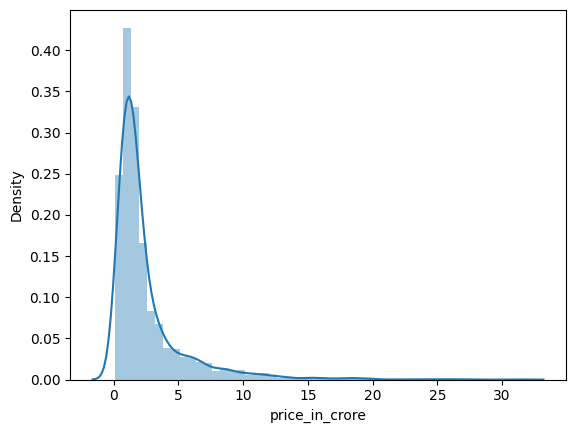

In [7]:
# outliers on the basis of price column
sns.distplot(df['price_in_crore'])

<Axes: xlabel='price_in_crore'>

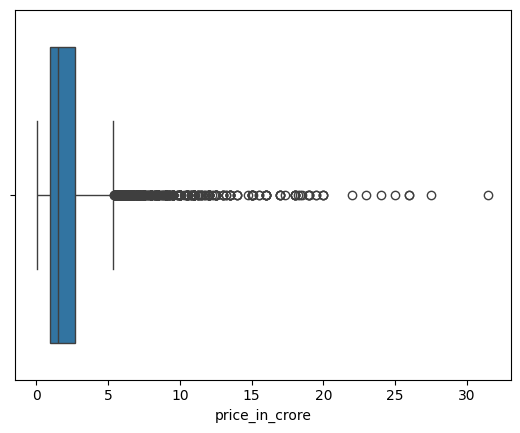

In [8]:
sns.boxplot(x=df['price_in_crore'])

In [9]:
# Calculate the IQR for the 'price' column
Q1 = df['price_in_crore'].quantile(0.25)
Q3 = df['price_in_crore'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price_in_crore'] < lower_bound) | (df['price_in_crore'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price_in_crore'].describe()

num_outliers, outliers_price_stats

(439,
 count    439.000000
 mean       9.164556
 std        4.049009
 min        5.400000
 25%        6.350000
 50%        8.000000
 75%       10.550000
 max       31.500000
 Name: price_in_crore, dtype: float64)

In [10]:
outliers.sort_values('price_in_crore',ascending=False).head(20)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
3718,house,arjun marg/ sector- 26 phase- 1/ golf course road,26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,0,0,2,74
3495,house,independent,43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,0,1,0,42
2398,house,independent,26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,0,0,0,72
770,house,dlf city plots,26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,0,1,0,138
586,house,suncity township,54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,0,0,1,0
529,house,emaar the palm springs,54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,0,0,0,122
614,house,independent,26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,0,0,0,145
922,house,vipul tatvam villa,48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,1,54
3380,house,dlf city plots,26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,0,0,0,153
2106,house,luxury dlf city floors,26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,0,31


In [11]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

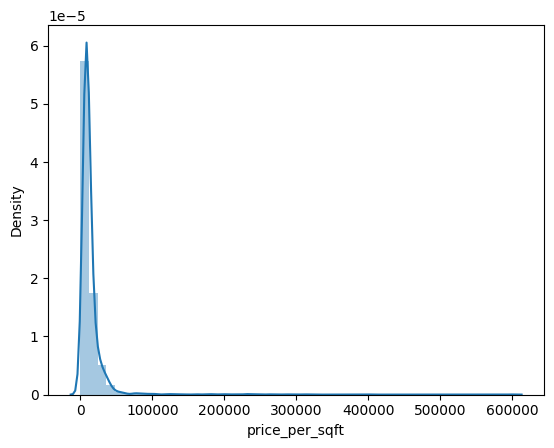

In [12]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

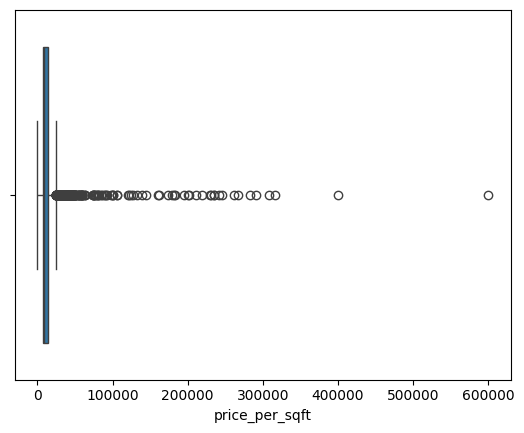

In [13]:
sns.boxplot(x=df['price_per_sqft'])

In [14]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(370,
 count       370.000000
 mean      53814.437838
 std       60724.418022
 min       24489.000000
 25%       28270.250000
 50%       33951.000000
 75%       44082.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [15]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [16]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price_in_crore']*10000000)/outliers_sqft['area'])

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\738830076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price_in_crore']*10000000)/outliers_sqft['area'])


In [17]:
outliers_sqft['price_per_sqft'].describe()

count      370.000000
mean     28697.086486
std      12662.601922
min       2723.000000
25%      25025.750000
50%      29587.500000
75%      35463.750000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [18]:
df.update(outliers_sqft)

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

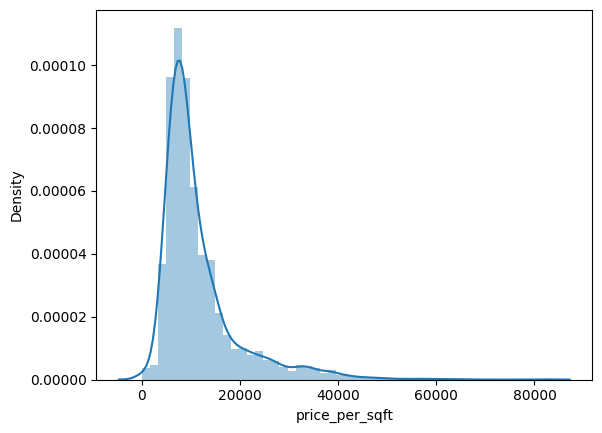

In [19]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

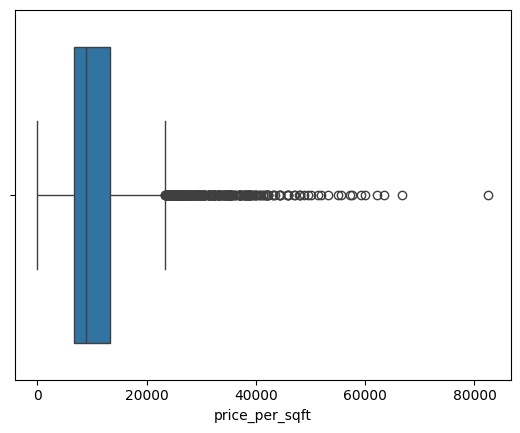

In [20]:
sns.boxplot(x=df['price_per_sqft'])

In [21]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
529,house,emaar the palm springs,54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,0,0,0,122
770,house,dlf city plots,26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,0,1,0,138
965,house,malibu towne,47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,0,99
1123,flat,unitech vistas,70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,1,0
1139,house,nul,28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,0,1,2,137
1701,house,independent,25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,0,0,0,72
1894,house,cloudnine cottages,48,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,1,0
2398,house,independent,26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,0,0,0,72
2480,house,emaar mgf marbella,66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,0,0,2,75
2694,house,project housing board colony,31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,1,0


In [22]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

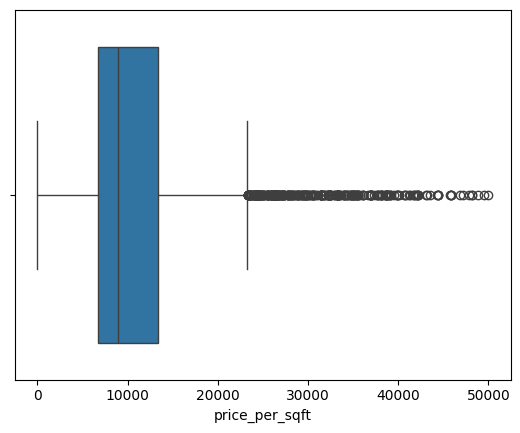

In [23]:
sns.boxplot(x=df['price_per_sqft'])

### Area

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

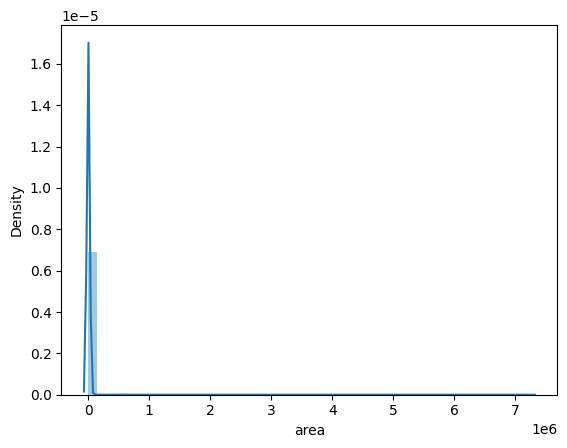

In [24]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

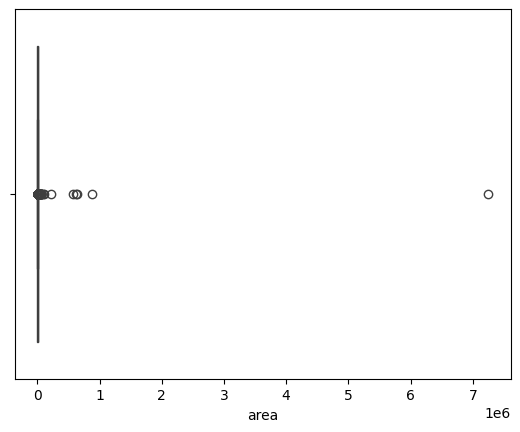

In [25]:
sns.boxplot(x=df['area'])

In [26]:
df['area'].describe()

count    3.790000e+03
mean     4.828231e+03
std      1.199030e+05
min      1.450000e+02
25%      1.245000e+03
50%      1.743000e+03
75%      2.340000e+03
max      7.250000e+06
Name: area, dtype: float64

In [27]:
df[df['area'] > 100000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
92,flat,hcbs sports ville,48,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
161,house,independent,10,1.45,2.0,7250000.0,Plot area 200(809372 sq.m.),4,3,3+,3.0,South,Moderately Old,NaN,200.0,NaN,0,0,0,0,0,1,0
428,flat,signature the roselia,95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,1,76
701,flat,signature global solera 2,107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,1,44
1044,flat,ramsons kshitij,95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,1,65
2668,house,independent,50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,0,1,0,0


In [28]:
df = df[df['area'] < 100000]

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

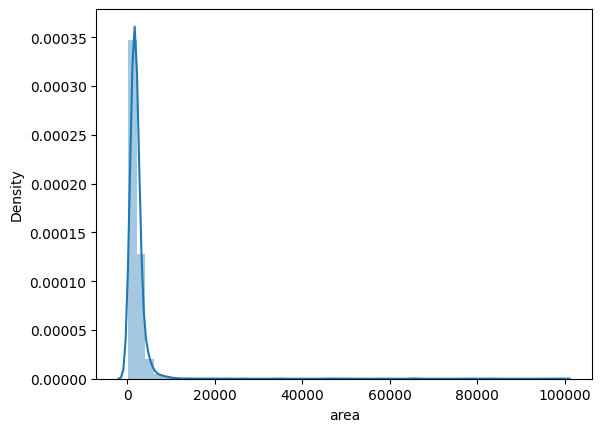

In [29]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

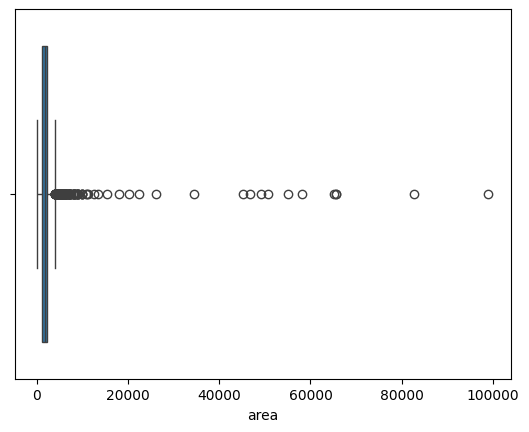

In [30]:
sns.boxplot(x=df['area'])

In [31]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
2541,house,independent,26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,0,0,0,60
2099,house,ganpati heights apartment,13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,1,7
3471,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,1,51
3045,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,1,15
2319,house,dlf city plot phase 4,28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
2490,flat,pyramid elite,86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,1,15
2004,flat,rof ananda,95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,1,37
1942,house,independent,51,5.50,1087.0,50598.0,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.0,North-East,Relatively New,NaN,8260.0,4860.00,0,0,0,0,0,0,49
2428,flat,signature the serenas,48,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,1,37
1691,house,independent,25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,0,109


In [32]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
2541,house,independent,26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,0,0,0,60
2099,house,ganpati heights apartment,13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,1,7
3471,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,1,51
3045,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,1,15
2319,house,dlf city plot phase 4,28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
2490,flat,pyramid elite,86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,1,15
2004,flat,rof ananda,95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,1,37
1942,house,independent,51,5.50,1087.0,50598.0,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.0,North-East,Relatively New,NaN,8260.0,4860.00,0,0,0,0,0,0,49
2428,flat,signature the serenas,48,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,1,37
1691,house,independent,25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,0,109


In [33]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

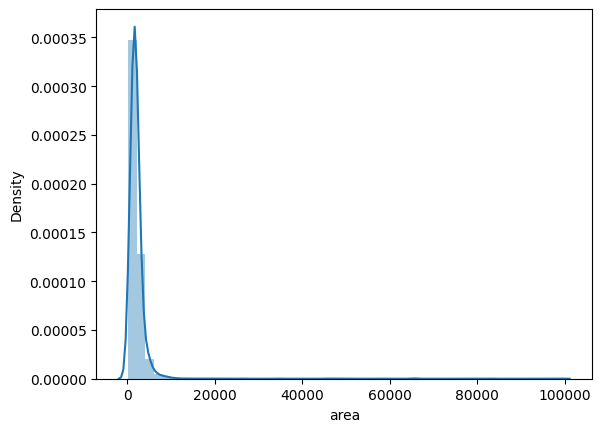

In [34]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

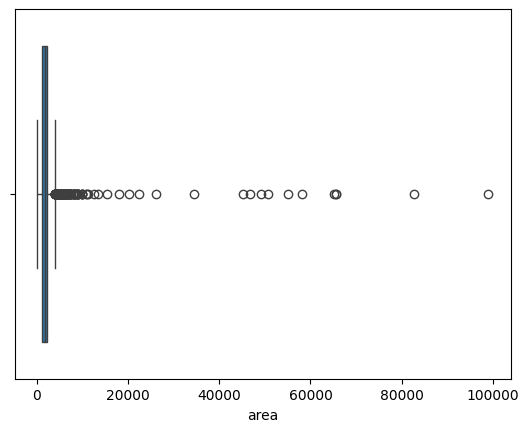

In [35]:
sns.boxplot(x=df['area'])

In [36]:
df['area'].describe()

count     3784.000000
mean      2149.163848
std       3671.399278
min        145.000000
25%       1245.000000
50%       1742.500000
75%       2338.500000
max      98978.000000
Name: area, dtype: float64

### Bedroom

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

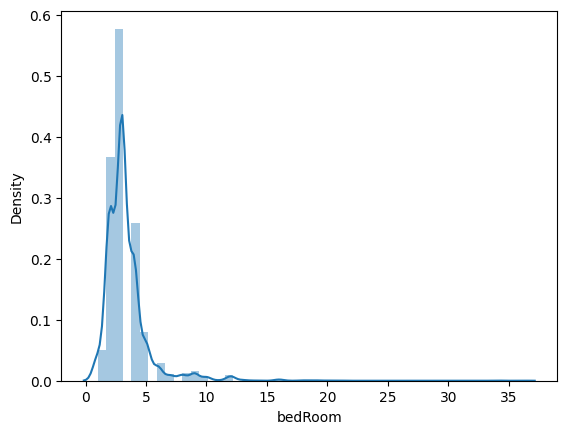

In [37]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

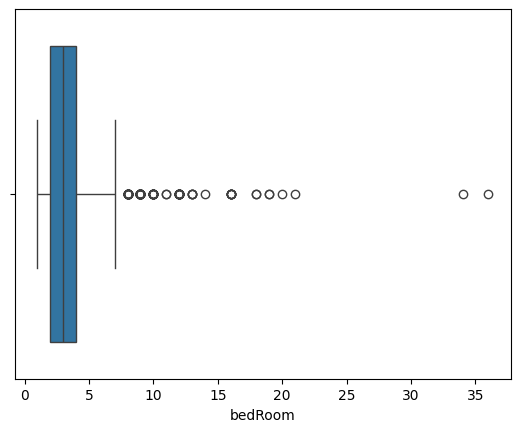

In [38]:
sns.boxplot(x=df['bedRoom'])

In [39]:
df['bedRoom'].describe()

count    3784.000000
mean        3.355444
std         1.972245
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        36.000000
Name: bedRoom, dtype: float64

In [40]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
953,house,independent,13,2.25,6944.0,3240.0,Plot area 360(301.01 sq.m.),36,36,2,3.0,East,Moderately Old,NaN,3240.0,NaN,0,1,0,0,0,1,7
2507,house,manohar nagar,8,5.60,12444.0,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 500 ...,34,34,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,0,0,0,0,0,0
3108,house,independent,54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,2,49
3050,house,independent,43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,2,22
2280,house,independent,17,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,1,68
592,house,independent,17,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,0,0,1,74
357,house,independent,54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,2,70
3566,house,private house,55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,2,57
3380,house,dlf city plots,26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,0,0,0,153
2106,house,luxury dlf city floors,26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,0,31


In [41]:
df = df[df['bedRoom'] <= 10]

In [42]:
df.shape

(3736, 23)

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

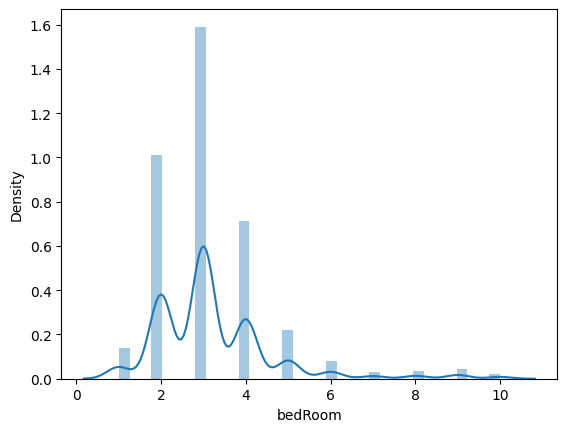

In [43]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

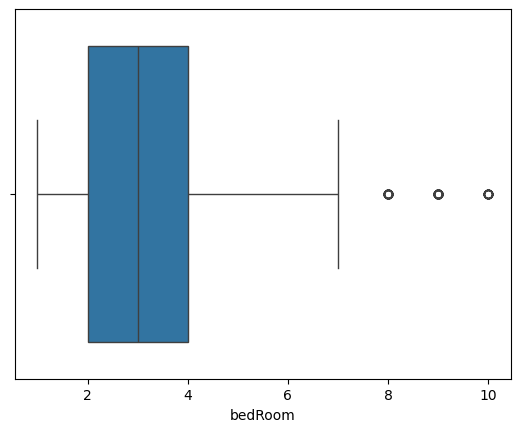

In [44]:
sns.boxplot(x=df['bedRoom'])

In [45]:
df['bedRoom'].describe()

count    3736.000000
mean        3.211991
std         1.413466
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

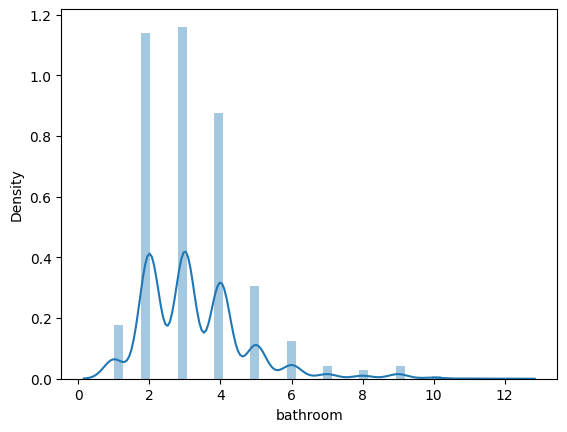

In [46]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

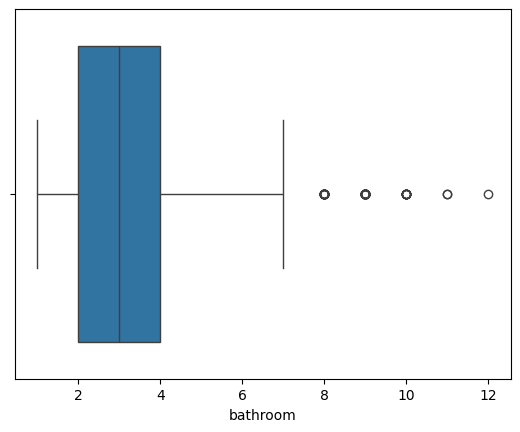

In [47]:
sns.boxplot(x=df['bathroom'])

In [48]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
3197,house,adani brahma samsara,60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,0,146
3339,house,independent,24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,0,1,0,39
3676,house,independent,39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,0,0,0,38


In [49]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,0,1,0,44
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,10.0,South-East,Relatively New,1741.0,1550.0,1350.0,0,0,0,0,1,1,49
2,house,independent,48,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,1.0,NaN,Relatively New,NaN,33.0,NaN,0,0,0,0,0,1,0
3,flat,brisk lumbini terrace homes,109,1.50,6616.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,4.0,North,New Property,NaN,NaN,2267.0,0,1,0,0,0,1,37
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,20.0,East,Moderately Old,2727.0,NaN,NaN,0,1,0,0,1,1,49


### super built up area

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

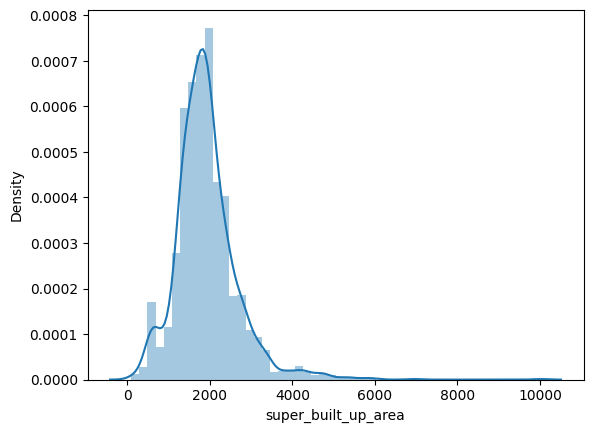

In [50]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

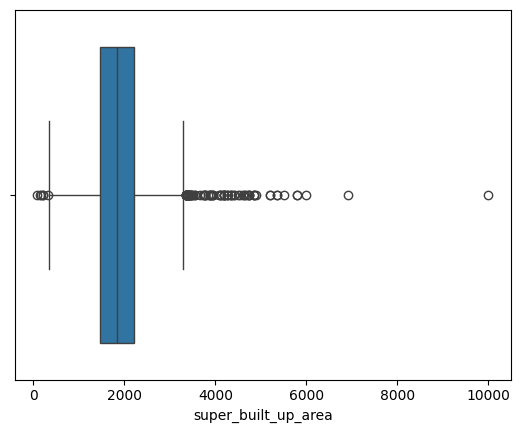

In [51]:
sns.boxplot(x=df['super_built_up_area'])

In [52]:
df['super_built_up_area'].describe()

count     1892.000000
mean      1920.820526
std        765.599753
min         89.000000
25%       1465.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [53]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
2383,flat,krrish provence estate,58,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,0,1,1,49
2929,flat,bestech park view grand spa,81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,0,140


### built up area

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

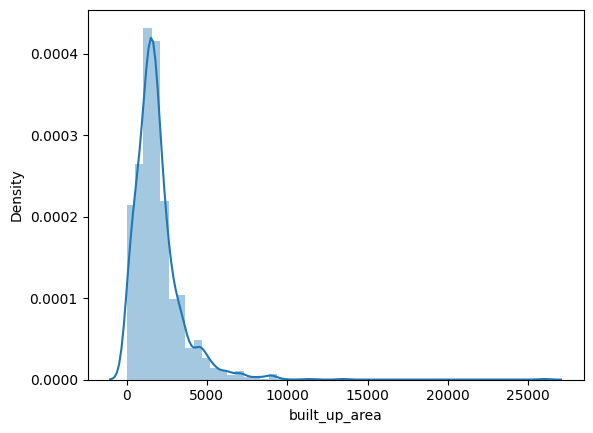

In [54]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

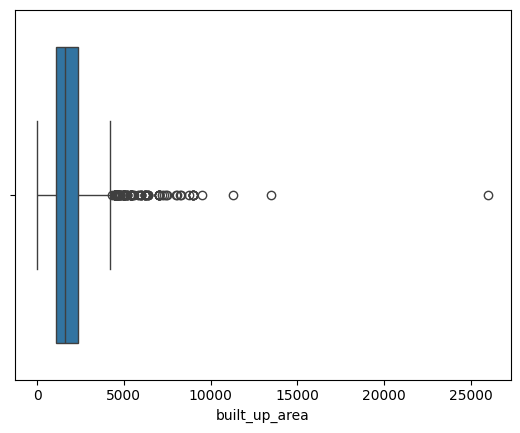

In [55]:
sns.boxplot(x=df['built_up_area'])

In [56]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
1613,house,independent,3,1.45,557.0,26032.0,Plot area 26000(2415.48 sq.m.),4,4,2,2.0,East,Moderately Old,NaN,26000.0,NaN,0,1,0,0,0,1,62
2606,house,independent,4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,1,0
3495,house,independent,43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,0,1,0,42


### carpet area

C:\Users\palas\AppData\Local\Temp\ipykernel_9696\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

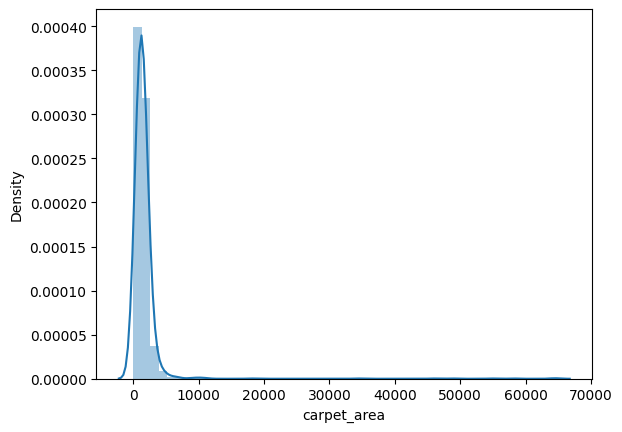

In [57]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

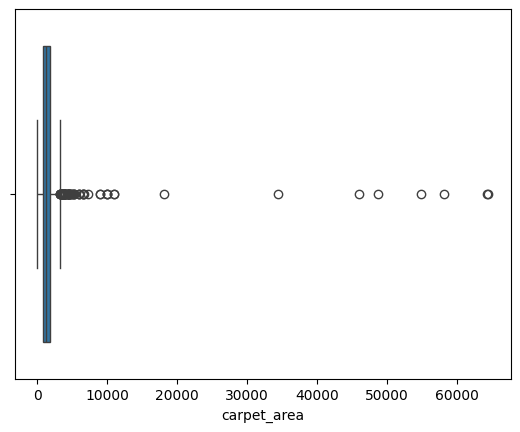

In [58]:
sns.boxplot(x=df['carpet_area'])

In [59]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,0,1,0,44
1090,flat,rof ananda,95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,North,Relatively New,NaN,NaN,34401.0,0,0,0,0,0,1,68
2004,flat,rof ananda,95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,1,37
2428,flat,signature the serenas,48,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,1,37
2490,flat,pyramid elite,86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,1,15
2541,house,independent,26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,0,0,0,60
3045,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.0,1,0,0,0,0,1,15
3471,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.0,0,0,0,0,0,1,51
3689,flat,ramsons kshitij,95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.0,0,0,0,0,1,1,33
3715,flat,m3m golfestate,65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,1,60


In [60]:
df.loc[2131,'carpet_area'] = 1812

In [61]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,0,1,0,44
1090,flat,rof ananda,95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,North,Relatively New,NaN,NaN,34401.0,0,0,0,0,0,1,68
2004,flat,rof ananda,95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,1,37
2428,flat,signature the serenas,48,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,1,37
2490,flat,pyramid elite,86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,1,15
2541,house,independent,26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,0,0,0,60
3045,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.0,1,0,0,0,0,1,15
3471,flat,rof ananda,95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.0,0,0,0,0,0,1,51
3689,flat,ramsons kshitij,95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.0,0,0,0,0,1,1,33
3715,flat,m3m golfestate,65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,1,60


In [62]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,0,1,0,44
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,10.0,South-East,Relatively New,1741.0,1550.0,1350.0,0,0,0,0,1,1,49
2,house,independent,48,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,1.0,NaN,Relatively New,NaN,33.0,NaN,0,0,0,0,0,1,0
3,flat,brisk lumbini terrace homes,109,1.50,6616.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,4.0,North,New Property,NaN,NaN,2267.0,0,1,0,0,0,1,37
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,20.0,East,Moderately Old,2727.0,NaN,NaN,0,1,0,0,1,1,49


C:\Users\palas\AppData\Local\Temp\ipykernel_9696\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

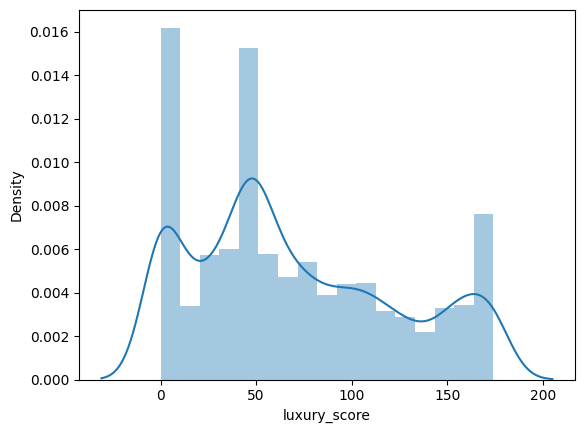

In [63]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

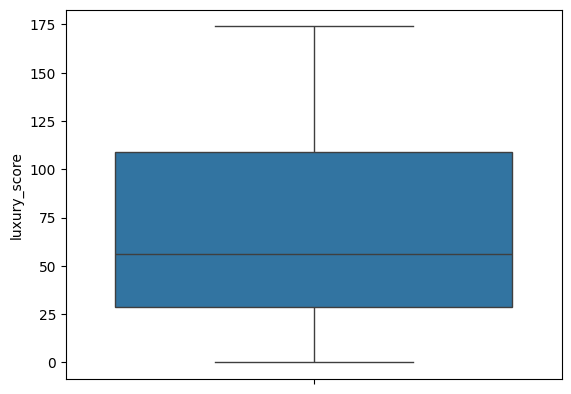

In [64]:
sns.boxplot(df['luxury_score'])

In [65]:
df.shape

(3736, 23)

In [66]:
df['price_per_sqft'] = round((df['price_in_crore']*10000000)/df['area'])

In [67]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,0,1,0,44
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,10.0,South-East,Relatively New,1741.0,1550.0,1350.0,0,0,0,0,1,1,49
2,house,independent,48,0.07,2527.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,1.0,NaN,Relatively New,NaN,33.0,NaN,0,0,0,0,0,1,0
3,flat,brisk lumbini terrace homes,109,1.50,6617.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,4.0,North,New Property,NaN,NaN,2267.0,0,1,0,0,0,1,37
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,20.0,East,Moderately Old,2727.0,NaN,NaN,0,1,0,0,1,1,49


C:\Users\palas\AppData\Local\Temp\ipykernel_9696\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

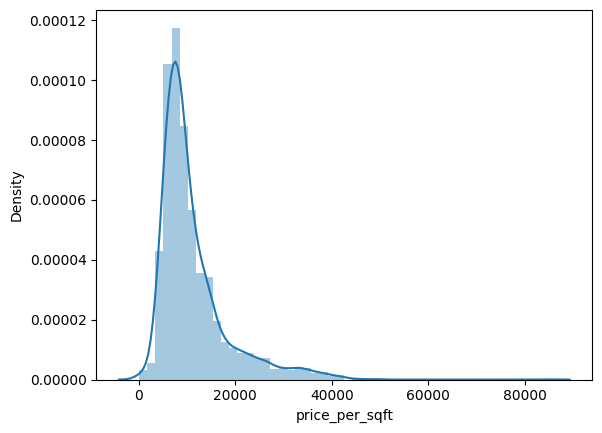

In [68]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

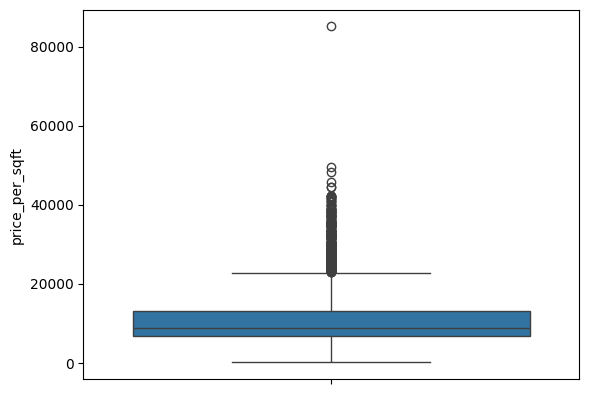

In [69]:
sns.boxplot(df['price_per_sqft'])

In [70]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
322,house,independent,28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,0,0,0,60
482,house,independent,26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,0,0,2,97
552,house,independent,25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,0,0,2,0
1538,house,independent,55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,0,44
2178,house,dlf city plots,26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,0,121
3397,house,independent,26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1,1,1,0,0,0,103
3438,house,independent,105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,1,0
3444,house,independent,24,10.0,85106.0,1175.0,Carpet area: 435 (40.41 sq.m.),8,10,3+,1.0,West,Undefined,NaN,NaN,435.0,0,0,0,0,0,1,0
3614,house,independent,43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,0,0,0,88
3642,house,sushant lok 1 builder floors,43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,0,0,0,0,0,7


In [71]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

np.float64(174.12)

In [72]:
df[(df['area']/df['bedRoom'])<183]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
13,house,independent,7,0.27,12000.0,225.0,Plot area 225(20.9 sq.m.),2,2,1,2.0,North-East,Moderately Old,NaN,225.0,NaN,0,0,0,0,0,1,12
27,house,independent,68,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0,0,0,0,0,1,0
144,house,independent,8,0.49,11239.0,436.0,Plot area 360(33.45 sq.m.),6,3,2,3.0,East,Moderately Old,NaN,360.0,NaN,0,0,0,0,0,1,8
155,house,sai kripa floors 5,11,0.90,11250.0,800.0,Plot area 800(74.32 sq.m.),5,5,3,3.0,NaN,Relatively New,NaN,800.0,NaN,0,0,0,0,0,1,0
273,house,independent,4,0.80,11852.0,675.0,Plot area 75(62.71 sq.m.),5,3,1,2.0,NaN,Moderately Old,NaN,675.0,NaN,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3538,house,not applicable,4,0.75,11719.0,640.0,Plot area 640(59.46 sq.m.),5,4,3,2.0,NaN,Moderately Old,NaN,640.0,NaN,0,0,0,0,0,1,0
3696,house,not applicable,4,0.51,14167.0,360.0,Plot area 40(33.45 sq.m.),4,4,3,4.0,NaN,New Property,NaN,360.0,NaN,0,0,0,0,0,1,0
3710,house,jacob pura,12,0.35,9722.0,360.0,Built Up area: 360 (33.45 sq.m.),2,1,0,NaN,NaN,Old Property,NaN,360.0,NaN,0,0,0,0,0,1,0
3825,house,independent,10,1.70,18889.0,900.0,Plot area 100(83.61 sq.m.)Built Up area: 61 sq...,5,4,3+,3.0,East,Moderately Old,NaN,61.0,60.0,0,0,0,0,0,1,34
